In [4]:
import numpy as np

num_samples_per_class = 1000

# create data points for negative and positive classes
negative_samples = np.random.multivariate_normal(mean=[0,3], 
                                                 cov=[[1, 0.5], [0.5, 1]],
                                                 size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(mean=[3, 0],
                                                 cov=[[1, 0.5], [0.5, 1]],
                                                 size=num_samples_per_class)

In [5]:
# Stack negative_samples and positive_samples into a single array (shape=(2000,2))
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [6]:
# Generate corresponding target labels (shape = (2000, 1)) as we have (2000, 2) data for inputs. This will be 3rd column added.
targets = np.vstack((
    np.zeros((num_samples_per_class, 1), dtype="float32"),
    np.ones((num_samples_per_class, 1), dtype="float32"),
))

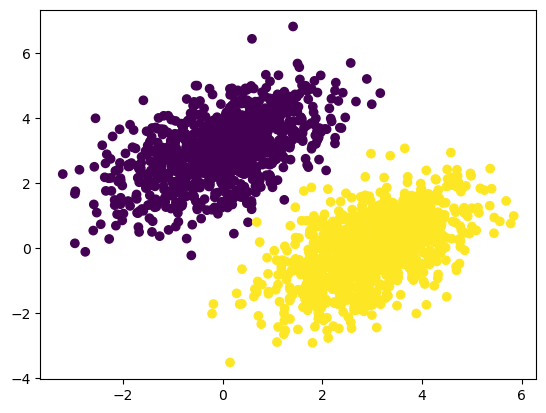

In [8]:
# lets plot
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:,1], c=targets[:,0])
plt.show()

In [9]:
import tensorflow as tf

In [10]:
# Inputs will be 2D points.
input_dim = 2

# The output predictions will be a single score per sample (close to 0
# if the sample is predicted to be in class 0, and close to 1 if the
# sample is predicted to be in class 1).
output_dim = 1

W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [11]:
# Forward pass function
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [12]:
# Loss function
def mean_squared_error(targets, predictions):
    # per_sample_losses will be a tensor with the same shape as targets
    # and predictions, containing per-sample loss scores.
    per_sample_losses = tf.square(targets - predictions)
    # We need to average these per-sample loss scores into a single
    # scalar loss value: reduce_mean does this.
    return tf.reduce_mean(per_sample_losses)

In [13]:
# we move to the training step, which receives some training data and updates 
# the weights W and b to minimize the loss on the data.
learning_rate = 0.1

# Wrap the function in a tf.function decorator to speed it up
@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    # Forward pass, inside of a gradient tape scope
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    # Retrieves the gradient of the loss with regard to weights
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    # Update the weights
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [14]:
# Training
for step in range(50):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

I0000 00:00:1778995834.574270   25818 service.cc:153] XLA service 0x5597db7fe350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778995834.574286   25818 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1050 Ti with Max-Q Design, Compute Capability 6.1 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778995834.581376   25818 cuda_dnn.cc:461] Loaded cuDNN version 92200


Loss at step 0: 2.1319
Loss at step 1: 0.3161
Loss at step 2: 0.1429
Loss at step 3: 0.1156
Loss at step 4: 0.1055
Loss at step 5: 0.0979
Loss at step 6: 0.0911
Loss at step 7: 0.0850
Loss at step 8: 0.0795
Loss at step 9: 0.0744
Loss at step 10: 0.0698
Loss at step 11: 0.0657
Loss at step 12: 0.0618
Loss at step 13: 0.0584
Loss at step 14: 0.0552
Loss at step 15: 0.0524
Loss at step 16: 0.0498
Loss at step 17: 0.0474
Loss at step 18: 0.0452
Loss at step 19: 0.0433
Loss at step 20: 0.0415
Loss at step 21: 0.0399
Loss at step 22: 0.0384
Loss at step 23: 0.0370
Loss at step 24: 0.0358
Loss at step 25: 0.0347
Loss at step 26: 0.0337
Loss at step 27: 0.0328
Loss at step 28: 0.0319
Loss at step 29: 0.0312
Loss at step 30: 0.0305
Loss at step 31: 0.0299
Loss at step 32: 0.0293
Loss at step 33: 0.0288
Loss at step 34: 0.0283
Loss at step 35: 0.0279
Loss at step 36: 0.0275
Loss at step 37: 0.0271
Loss at step 38: 0.0268
Loss at step 39: 0.0265
Loss at step 40: 0.0262
Loss at step 41: 0.0260
Lo

I0000 00:00:1778995835.037941   25818 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


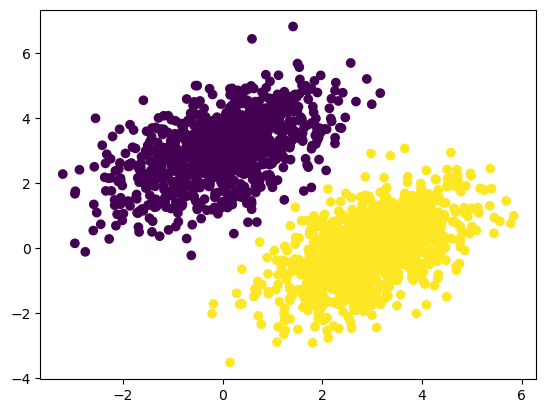

In [15]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

In [16]:
W[0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.16765815], dtype=float32)>

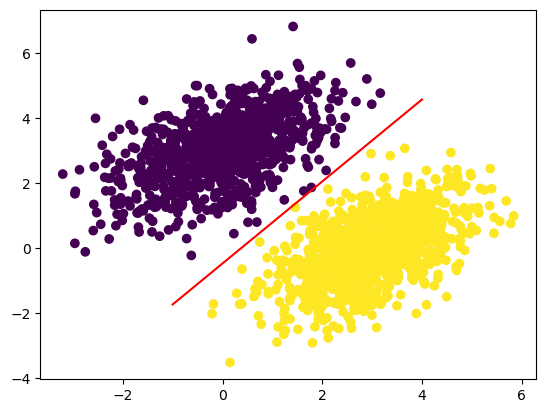

In [17]:

# Generates 100 regularly spaced numbers between -1 and 4, which we
# will use to plot our line
x = np.linspace(-1, 4, 100)
# This is our line's equation.
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
# Plots our line (`"-r"` means "plot it as a red line")
plt.plot(x, y, "-r")
# Plots our model's predictions on the same plot
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)